# Дослідницький аналіз даних (Exploratory Data Analysis)

## Мета

Виконати дослідницький аналіз набору даних, дослідити розподіли ознак, взаємозв'язки між ними та визначити потенційні особливості, які можуть вплинути на побудову моделей машинного навчання.

In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import sys
import importlib
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# CONNECT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# ============================================================
# LOAD PROJECT MODULES
# ============================================================

PROJECT_PATH = "/content/drive/MyDrive/FitnessML_Master"

if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)

importlib.invalidate_caches()

import config
import utils

config = importlib.reload(config)
utils = importlib.reload(utils)

utils.section("Project modules")

print("✓ config.py loaded")
print("✓ utils.py loaded")


PROJECT MODULES
✓ config.py loaded
✓ utils.py loaded


In [4]:
# ============================================================
# LOAD DATASET
# ============================================================

utils.section("Dataset")

df = utils.load_dataset()

df["date"] = pd.to_datetime(df["date"])

utils.set_plot_style()

print("✓ Dataset loaded")
print(config.DATASET_NAME)


DATASET
✓ Dataset loaded
health_fitness_tracking_365days.csv


## Загальна характеристика датасету

На даному етапі виконується первинна статистична оцінка числових ознак набору даних.

Метою є визначення діапазону значень, середніх величин, стандартних відхилень та виявлення потенційних аномалій, які можуть вплинути на подальше моделювання.

In [6]:
utils.section("Descriptive statistics")
describe = df.describe().T

display(
    utils.rename_columns(describe)
)


DESCRIPTIVE STATISTICS


,count,mean,min,25%,50%,75%,max,std
user_id,365000.0,499.5,0.0,249.75,499.5,749.25,999.0,288.675386
age,365000.0,48.772,18.0,33.0,49.0,64.0,79.0,17.792832
date,365000,2025-03-07 00:00:00.000000512,2024-09-06 00:00:00,2024-12-06 00:00:00,2025-03-07 00:00:00,2025-06-06 00:00:00,2025-09-05 00:00:00,NaN
steps,365000.0,8499.532058,5723.0,7248.0,8497.0,9750.0,11330.0,1446.826636
heart_rate_avg,365000.0,64.979414,13.801607,57.390843,64.997519,72.550623,113.325619,11.246659
sleep_hours,365000.0,7.003109,3.0,5.990209,7.000849,8.015041,12.0,1.495827
calories_burned,365000.0,1999.942722,505.956221,1797.603287,1999.980702,2201.965489,3408.341803,300.05845
exercise_minutes,365000.0,30.054553,0.000025,8.600785,20.784057,41.66498,487.105147,30.145841
stress_level,365000.0,5.50197,1.0,3.0,6.0,8.0,10.0,2.872646
weight_kg,365000.0,70.011188,4.32727,59.90027,69.995579,80.138985,138.765278,15.005358


## Аналіз розподілу ознак

Гістограми дозволяють оцінити форму розподілу числових характеристик, визначити наявність асиметрії, мультимодальності та потенційних викидів.

Отримані результати використовуються для вибору методів нормалізації та подальшої підготовки даних.


FEATURE DISTRIBUTIONS


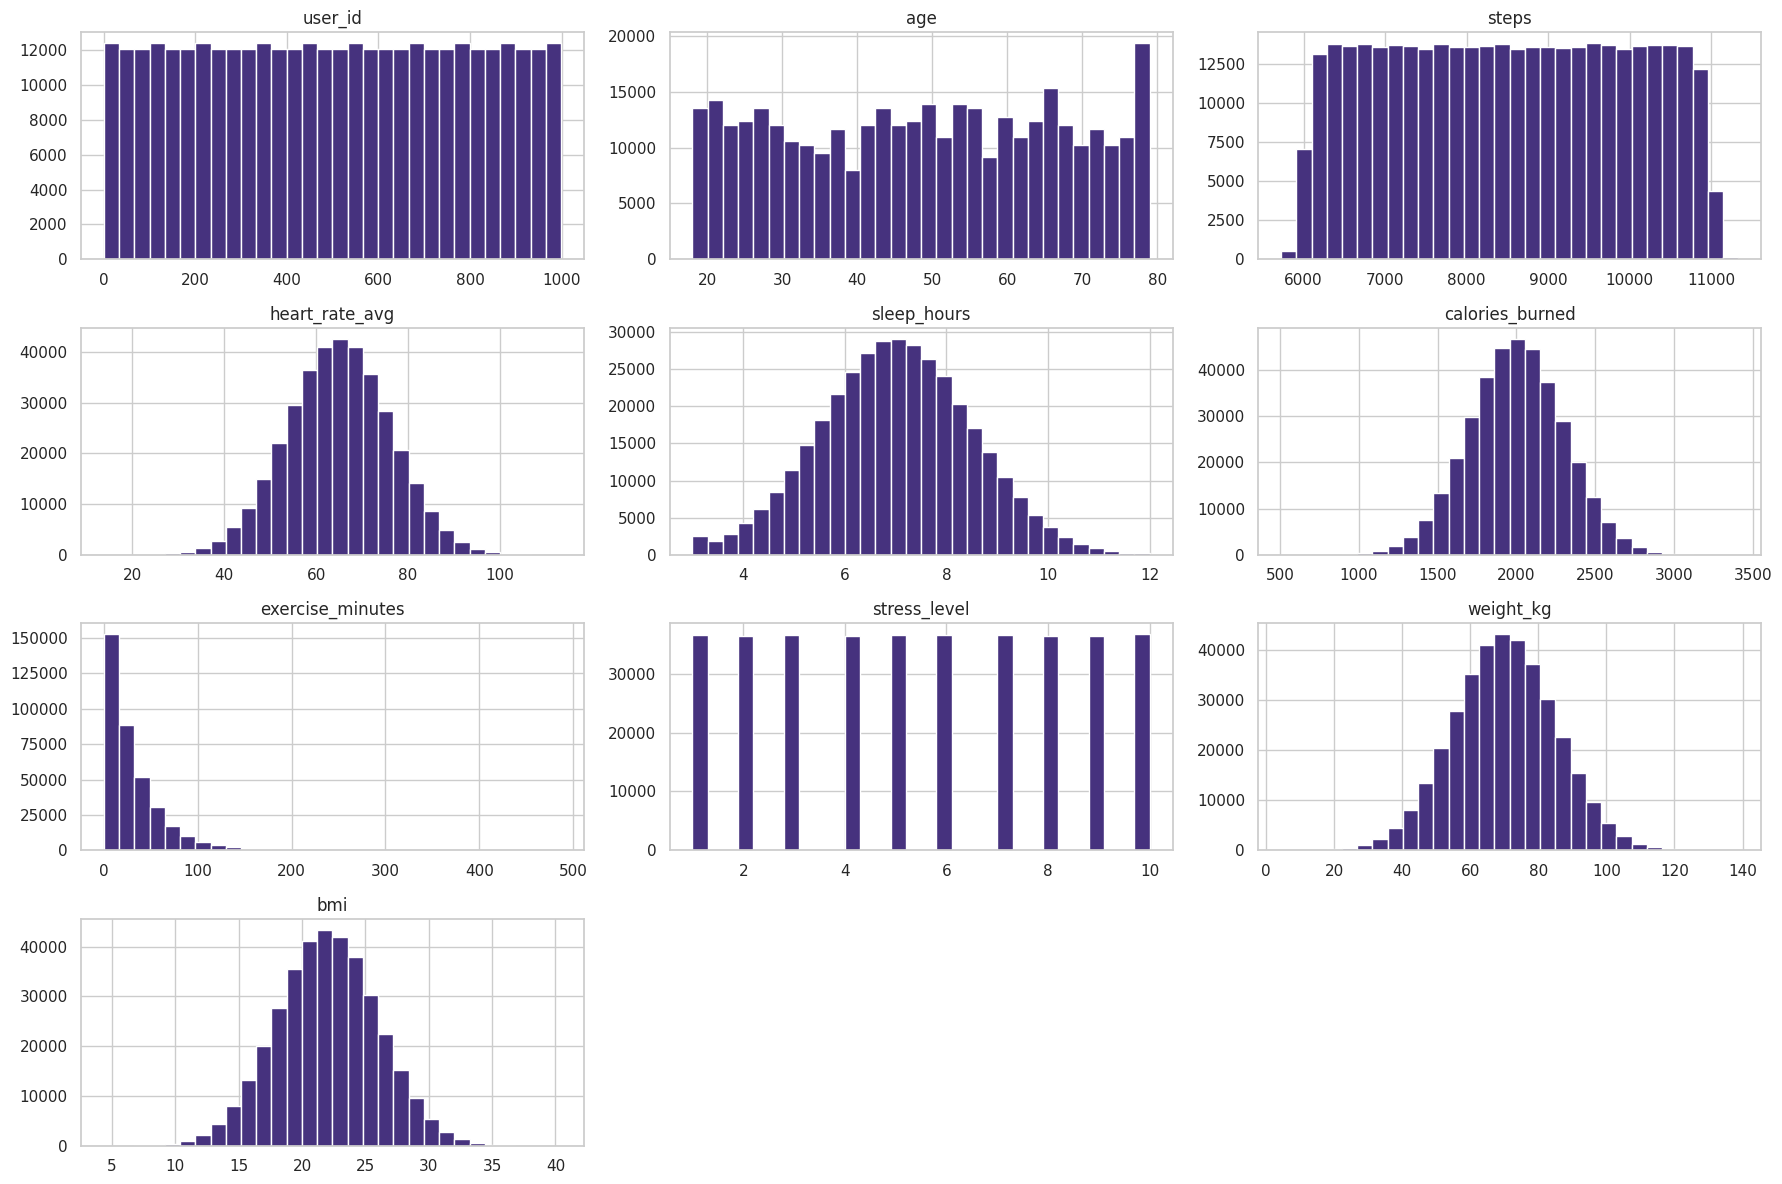

✓ Figure saved -> /content/drive/MyDrive/FitnessML_Master/figures/02_histograms.png


In [9]:
utils.section("Feature distributions")
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].hist(
    figsize=(18,12),
    bins=30
)

plt.tight_layout()
plt.show()
utils.save_figure(
    plt.gcf(),
    "02_histograms.png"
)

## Аналіз викидів

Діаграми типу BoxPlot використовуються для візуального визначення можливих аномальних значень.

Наявність значної кількості викидів може вплинути на точність моделей машинного навчання та вимагати додаткової обробки.

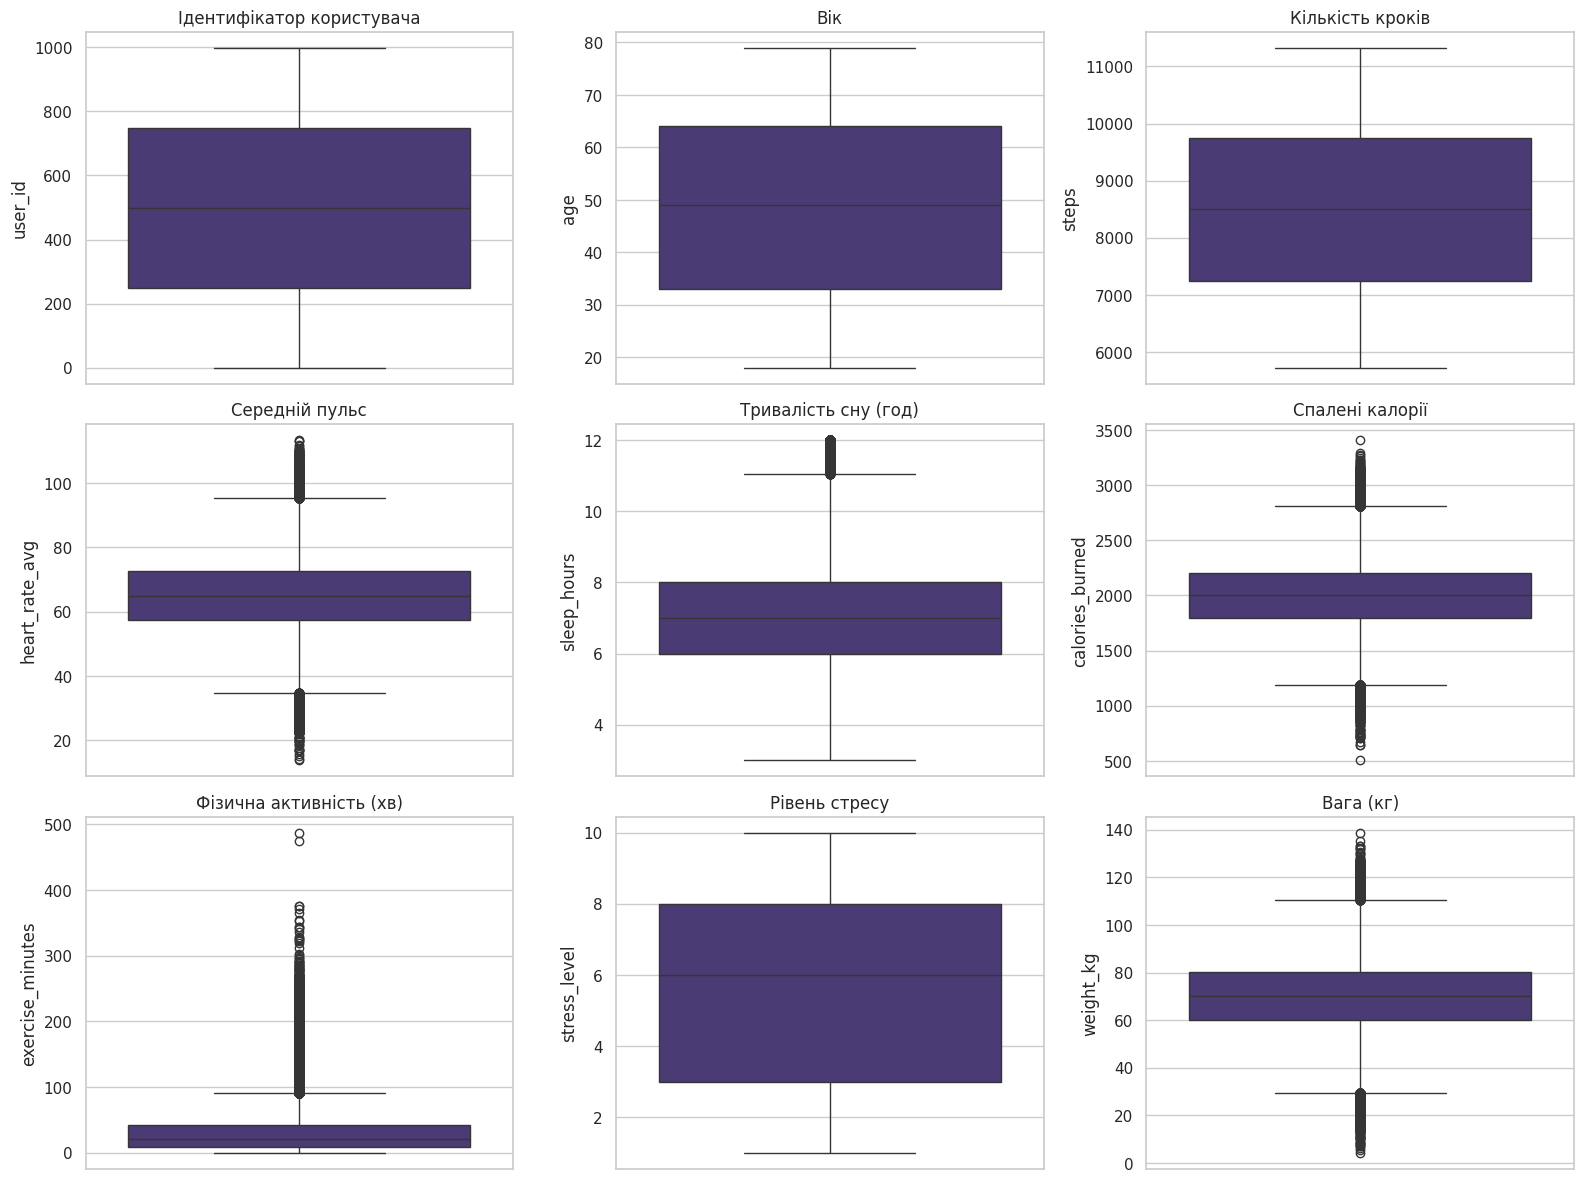

✓ Figure saved -> /content/drive/MyDrive/FitnessML_Master/figures/02_boxplots.png


In [13]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for ax, column in zip(axes.flat, numeric_columns):

    sns.boxplot(
        y=df[column],
        ax=ax
    )

    ax.set_title(
        utils.label(column)
    )

plt.tight_layout()
plt.show()
utils.save_figure(
    fig,
    "02_boxplots.png"
)

In [14]:
gender = (
    utils.localize_values(
        df["gender"]
    )
    .value_counts()
)

display(gender)

,count
gender,
Жінка,186515
Чоловік,178485


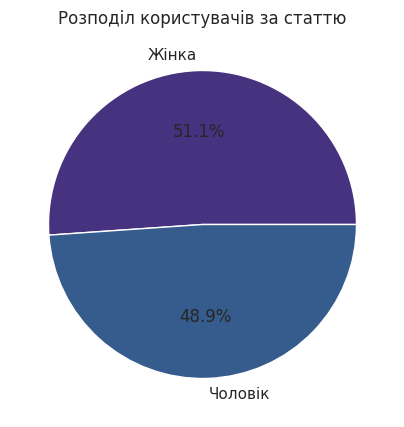

✓ Figure saved -> /content/drive/MyDrive/FitnessML_Master/figures/02_gender_distribution.png


In [16]:
fig = plt.figure(figsize=(5,5))

gender.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Розподіл користувачів за статтю")
plt.show()
utils.save_figure(fig, "02_gender_distribution.png")

## Кореляційний аналіз

Кореляційна матриця використовується для визначення сили лінійного взаємозв'язку між числовими ознаками.

Результати дозволяють виявити мультиколінеарність та визначити найбільш інформативні характеристики для подальшого моделювання.

In [18]:
utils.section("Correlation analysis")
corr = df[numeric_columns].corr()

display(
    utils.rename_columns(
        corr.round(2)
    )
)


CORRELATION ANALYSIS


,Ідентифікатор користувача,Вік,Кількість кроків,Середній пульс,Тривалість сну (год),Спалені калорії,Фізична активність (хв),Рівень стресу,Вага (кг),Індекс маси тіла
user_id,1.00,-0.07,0.0,0.02,0.0,-0.0,-0.0,0.0,0.0,0.0
age,-0.07,1.00,0.0,-0.16,-0.0,-0.0,0.0,-0.0,-0.0,0.0
steps,0.00,0.00,1.0,0.00,-0.0,0.0,0.0,-0.0,0.0,-0.0
heart_rate_avg,0.02,-0.16,0.0,1.00,-0.0,0.0,0.0,0.0,-0.0,0.0
sleep_hours,0.00,-0.00,-0.0,-0.00,1.0,-0.0,0.0,-0.0,-0.0,-0.0
calories_burned,-0.00,-0.00,0.0,0.00,-0.0,1.0,0.0,-0.0,0.0,-0.0
exercise_minutes,-0.00,0.00,0.0,0.00,0.0,0.0,1.0,0.0,0.0,-0.0
stress_level,0.00,-0.00,-0.0,0.00,-0.0,-0.0,0.0,1.0,0.0,-0.0
weight_kg,0.00,-0.00,0.0,-0.00,-0.0,0.0,0.0,0.0,1.0,0.0
bmi,0.00,0.00,-0.0,0.00,-0.0,-0.0,-0.0,-0.0,0.0,1.0


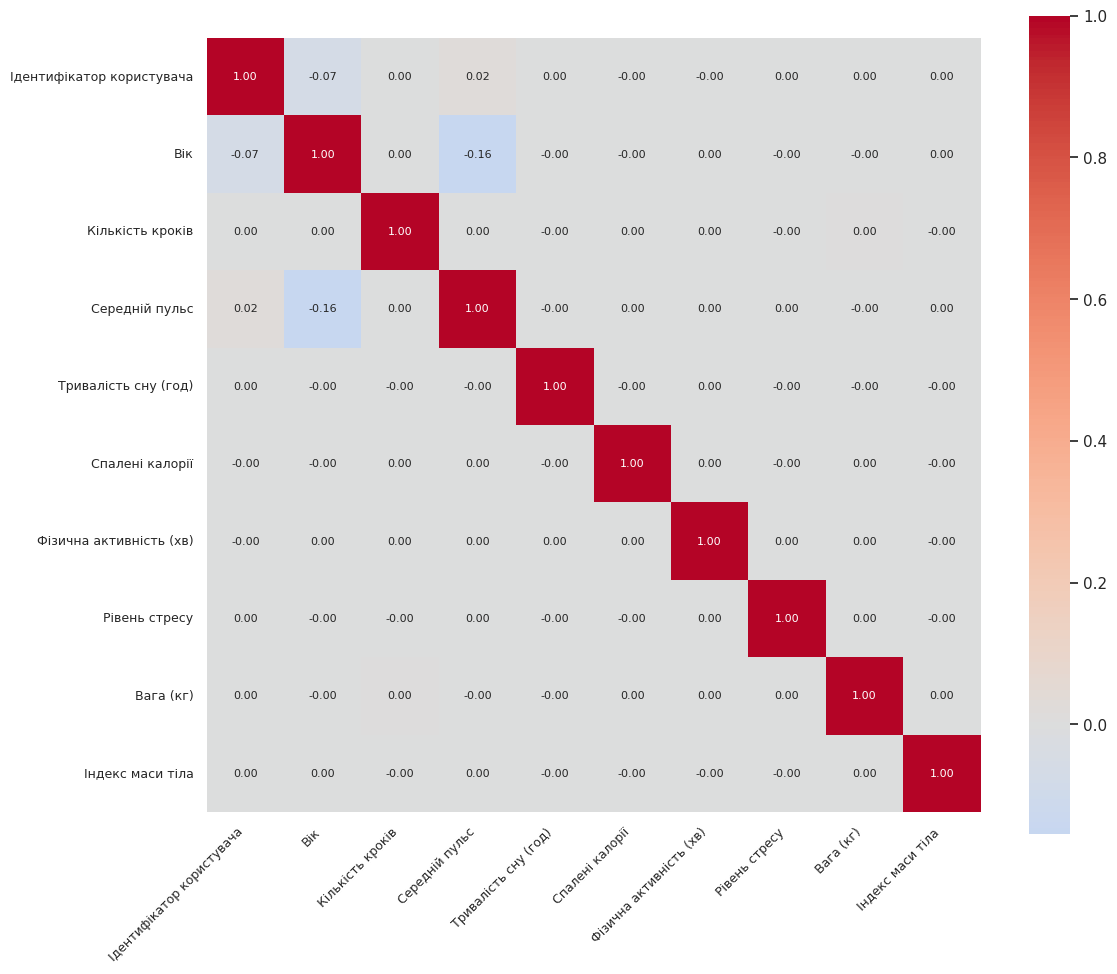

✓ Figure saved -> /content/drive/MyDrive/FitnessML_Master/figures/02_correlation_matrix.png


In [21]:
fig = plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    xticklabels=[utils.label(c) for c in corr.columns],
    yticklabels=[utils.label(c) for c in corr.columns],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    annot_kws={"size": 8}
)

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=9
)

plt.yticks(
    rotation=0,
    fontsize=9
)

plt.tight_layout()
plt.show()
utils.save_figure(
    fig,
    "02_correlation_matrix.png"
)

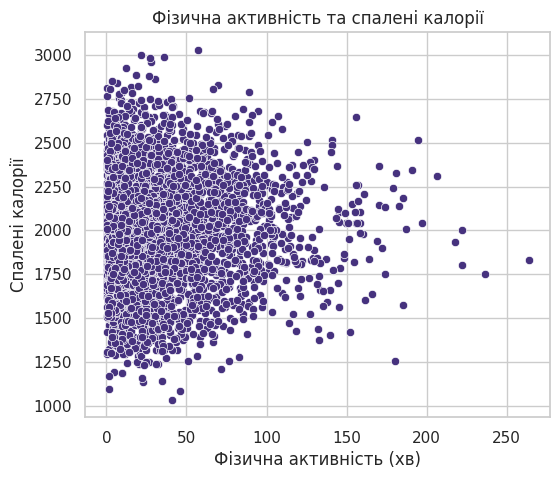

✓ Figure saved -> /content/drive/MyDrive/FitnessML_Master/figures/02_exercise_calories.png


In [23]:
fig = plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df.sample(5000, random_state=config.RANDOM_STATE),
    x="exercise_minutes",
    y="calories_burned"
)

plt.xlabel(
    utils.label("exercise_minutes")
)

plt.ylabel(
    utils.label("calories_burned")
)

plt.title(
    "Фізична активність та спалені калорії"
)
plt.show()
utils.save_figure(fig, "02_exercise_calories.png")

In [ ]:
user = df["user_id"].sample(
    1,
    random_state=config.RANDOM_STATE
).iloc[0]

user_df = df[df["user_id"] == user]


WEIGHT TIME SERIES


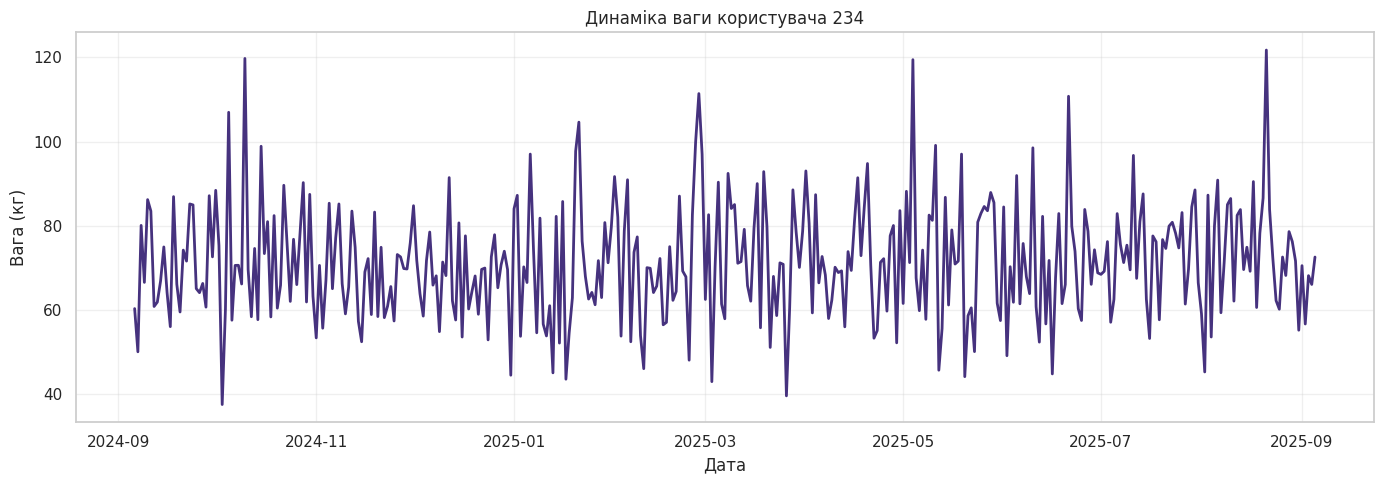

✓ Figure saved -> /content/drive/MyDrive/FitnessML_Master/figures/02_weight_timeseries.png


In [26]:
utils.section("Weight time series")

user = df["user_id"].sample(
    1,
    random_state=config.RANDOM_STATE
).iloc[0]

user_df = df[df["user_id"] == user]

fig = plt.figure(figsize=(14, 5))

plt.plot(
    user_df["date"],
    user_df["weight_kg"],
    linewidth=2
)

plt.title(
    f"Динаміка ваги користувача {user}"
)

plt.xlabel("Дата")

plt.ylabel(
    utils.label("weight_kg")
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
utils.save_figure(
    fig,
    "02_weight_timeseries.png"
)

In [27]:
utils.save_table_ua(
    corr,
    "02_correlation_matrix.csv"
)

utils.save_table_ua(
    gender.to_frame(),
    "02_gender_distribution.csv"
)

✓ Table saved -> /content/drive/MyDrive/FitnessML_Master/tables/02_correlation_matrix.csv
✓ Table saved -> /content/drive/MyDrive/FitnessML_Master/tables/02_gender_distribution.csv


In [31]:
# ============================================================
# REPORT
# ============================================================

corr_pairs = (
    corr.where(~np.eye(len(corr), dtype=bool))
        .stack()
        .sort_values()
)

strongest_negative = corr_pairs.index[0]
strongest_positive = corr_pairs.index[-1]

negative_value = corr_pairs.iloc[0]
positive_value = corr_pairs.iloc[-1]

report = f"""# Exploratory Data Analysis

## Dataset

- Records: {len(df):,}
- Features: {len(df.columns)}

## Gender distribution

{gender.to_markdown()}

## Correlation analysis

Strongest positive correlation:

- **{utils.label(strongest_positive[0])} ↔ {utils.label(strongest_positive[1])}**
- Correlation coefficient: **{positive_value:.3f}**

Strongest negative correlation:

- **{utils.label(strongest_negative[0])} ↔ {utils.label(strongest_negative[1])}**
- Correlation coefficient: **{negative_value:.3f}**

## Generated files

### Figures

- 02_histograms.png
- 02_boxplots.png
- 02_gender_distribution.png
- 02_correlation_matrix.png
- 02_exercise_calories.png
- 02_weight_timeseries.png

### Tables

- 02_gender_distribution.csv
- 02_correlation_matrix.csv
"""
utils.save_report(
    report,
    "02_eda.md"
)

✓ Report saved -> /content/drive/MyDrive/FitnessML_Master/reports/02_eda.md


In [28]:
utils.section("EDA completed")


EDA COMPLETED
